# EDA Marketing History

Черновой ноутбук. Добавляйте код и выводы по мере анализа.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [17]:
marketing = pd.read_excel(
    "../data/raw/marketing_history.xlsx",
    header=2
)

print("Размер данных:", marketing.shape)
marketing.head()

Размер данных: (210, 40)


,event_id,event_time,source_channel,activity_type,course,campaign,placement,creative_text,external_or_internal,post_url,...,raw_ad_marking,raw_erid,raw_scraped_at,raw_html_ref,Unnamed: 34,product_scope,product_line,inferred_course,content_direction,candidate_courses
0,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов (авто),ML старт | Data Science,NaN,postypashki_old/1764,Самые интересные события в ближайшее время.\nВ...,internal,https://t.me/postypashki_old/1764,...,NaN,False,2026-07-01T15:10:49+00:00,NaN,NaN,multiple_courses,START,NaN,career,ML старт | Data science
1,INT-1765,2026-07-02 18:31:22,@postypashki_old,Прочий контент (авто),NaN,NaN,postypashki_old/1765,"В новом ролике обсудим, что с вашей психикой с...",internal,https://t.me/postypashki_old/1765,...,NaN,False,2026-07-02T15:31:22+00:00,NaN,NaN,unknown,NaN,NaN,career,NaN
2,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой (авто),NaN,NaN,postypashki_old/1767,❗️ Завтра заканчивается донабор на стажировку ...,internal,https://t.me/postypashki_old/1767,...,NaN,False,2026-07-04T09:03:55+00:00,NaN,NaN,product_line,START,NaN,career,Аналитика старт | Алгоритмы старт | Backend ст...
3,INT-1768,2026-07-04 15:35:53,@postypashki_old,Контент с предложением курсов (авто),ML старт,NaN,postypashki_old/1768,Академия Авито и Буткем Авито \n\nСегодня прош...,internal,https://t.me/postypashki_old/1768,...,NaN,False,2026-07-04T12:35:53+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт
4,INT-1770,2026-07-05 16:51:14,@postypashki_old,Прочий контент (авто),ML старт,NaN,postypashki_old/1770,Как затащить МЛ собеседование в 2026 году \n\n...,internal,https://t.me/postypashki_old/1770,...,NaN,False,2026-07-05T13:51:14+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт


In [18]:
# Убираем полностью пустые столбцы
marketing = marketing.dropna(axis=1, how="all")

print("Размер после очистки:", marketing.shape)
marketing.head()

Размер после очистки: (210, 38)


,event_id,event_time,source_channel,activity_type,course,placement,creative_text,external_or_internal,post_url,views,...,raw_ad_marking,raw_erid,raw_scraped_at,raw_html_ref,Unnamed: 34,product_scope,product_line,inferred_course,content_direction,candidate_courses
0,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов (авто),ML старт | Data Science,postypashki_old/1764,Самые интересные события в ближайшее время.\nВ...,internal,https://t.me/postypashki_old/1764,21200,...,NaN,False,2026-07-01T15:10:49+00:00,NaN,NaN,multiple_courses,START,NaN,career,ML старт | Data science
1,INT-1765,2026-07-02 18:31:22,@postypashki_old,Прочий контент (авто),NaN,postypashki_old/1765,"В новом ролике обсудим, что с вашей психикой с...",internal,https://t.me/postypashki_old/1765,17500,...,NaN,False,2026-07-02T15:31:22+00:00,NaN,NaN,unknown,NaN,NaN,career,NaN
2,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой (авто),NaN,postypashki_old/1767,❗️ Завтра заканчивается донабор на стажировку ...,internal,https://t.me/postypashki_old/1767,18600,...,NaN,False,2026-07-04T09:03:55+00:00,NaN,NaN,product_line,START,NaN,career,Аналитика старт | Алгоритмы старт | Backend ст...
3,INT-1768,2026-07-04 15:35:53,@postypashki_old,Контент с предложением курсов (авто),ML старт,postypashki_old/1768,Академия Авито и Буткем Авито \n\nСегодня прош...,internal,https://t.me/postypashki_old/1768,20400,...,NaN,False,2026-07-04T12:35:53+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт
4,INT-1770,2026-07-05 16:51:14,@postypashki_old,Прочий контент (авто),ML старт,postypashki_old/1770,Как затащить МЛ собеседование в 2026 году \n\n...,internal,https://t.me/postypashki_old/1770,19000,...,NaN,False,2026-07-05T13:51:14+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт


In [24]:
marketing = marketing.drop(columns=["Unnamed: 34"])

## 1. Общий обзор датасета

Сначала посмотрим на размер маркетинговой истории, временной диапазон,
количество уникальных событий и базовую полноту данных.

In [34]:
print(f"Количество маркетинговых событий: {len(marketing)}")
print(f"Количество столбцов: {marketing.shape[1]}")
print(f"Уникальных event_id: {marketing['event_id'].nunique()}")
print(f"Дубликатов event_id: {marketing['event_id'].duplicated().sum()}")

Количество маркетинговых событий: 210
Количество столбцов: 37
Уникальных event_id: 210
Дубликатов event_id: 0


## Основные поля датасета

| Поле | Что это значит | Как использовать в анализе |
|---|---|---|
| `event_id` | Уникальный ID маркетингового события | Ключ строки, проверка дубликатов |
| `event_time` | Дата и время публикации | Нужен для временного анализа и связи с продажами |
| `source_channel` | Канал, где вышло событие | Сравнение источников маркетинга |
| `activity_type` | Тип маркетинговой активности | Показывает формат воздействия: промо, скидка, контент, запуск и т.д. |
| `creative_text` | Текст публикации | Источник контекста для определения продуктовой связи |
| `external_or_internal` | Внутренний или внешний источник | Разделение собственных и внешних активностей |
| `views` | Просмотры публикации | Оценка масштаба охвата |
| `reactions` | Реакции на публикацию | Оценка вовлечённости |
| `cost_rub` | Стоимость размещения | Нужна для оценки эффективности и ROMI |
| `product_scope` | Уровень продуктовой привязки события | Показывает, относится событие к одному курсу, нескольким курсам, линейке, бренду, внешнему продукту или связь не определена |
| `product_line` | Линейка продукта | `START`, `PRO` или обе; нужна для анализа на уровне линейки |
| `content_direction` | Тематика публикации | Показывает, о чём пост, независимо от того, что именно продаётся |
| `course` | Исходная продуктовая разметка из собранных данных. Может содержать как реальные названия курсов, так и темы/навыки, упомянутые в тексте | Используется как исходное поле для контроля и проверки разметки. Не считается финальным полем для связи с продажами |
| `inferred_course` | Уточнённый конкретный курс или несколько курсов, которые мы считаем реально продвигаемыми после чтения текста и контекста | Используется для более точной интерпретации события. Отбрасывает случаи, где в `course` были просто темы вроде `АВ тестам`, `Дискретка`, если они не являются отдельным продаваемым продуктом |
| `candidate_courses` | Список официальных курсов, продажи которых имеет смысл проверять после данного события | Главное поле для связи маркетинга с продажами. Может совпадать с `inferred_course`, а может быть шире, например при продвижении всей линейки START или PRO |

## 2. Качество данных

Проверим пропуски и убедимся, что ключевые поля для дальнейшего анализа заполнены корректно.

Важно учитывать, что часть пропусков является ожидаемой:
например, `product_line` не обязана быть определена для внешних или общебрендовых событий,
а стоимость размещения известна не для всех публикаций.

In [35]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   event_id              210 non-null    object        
 1   event_time            210 non-null    datetime64[ns]
 2   source_channel        210 non-null    object        
 3   activity_type         210 non-null    object        
 4   course                35 non-null     object        
 5   placement             210 non-null    object        
 6   creative_text         193 non-null    object        
 7   external_or_internal  210 non-null    object        
 8   post_url              210 non-null    object        
 9   views                 210 non-null    int64         
 10  reactions             189 non-null    float64       
 11  data_source           210 non-null    object        
 12  confidence            210 non-null    object        
 13  collected_by        

In [36]:
missing = (
    marketing.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .to_frame("missing_%")
)

missing

,missing_%
raw_ad_marking,98.6
course,83.3
raw_media,77.6
raw_forwarded_from,76.7
inferred_course,58.6
raw_discount_flag,53.8
raw_period,53.8
raw_scraped_at,53.8
raw_offer_flag,53.8
raw_lead_magnet_flag,53.8


In [37]:
key_cols = [
    "event_time",
    "source_channel",
    "activity_type",
    "external_or_internal",
    "product_scope",
    "product_line",
    "inferred_course",
    "content_direction",
    "candidate_courses",
    "views",
    "reactions",
]

(
    marketing[key_cols]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .to_frame("missing_%")
)

,missing_%
event_time,0.0
source_channel,0.0
activity_type,0.0
external_or_internal,0.0
product_scope,0.0
product_line,48.1
inferred_course,58.6
content_direction,0.0
candidate_courses,45.7
views,0.0


## 3. Временной охват маркетинговой истории

Маркетинговая история начинается раньше периода продаж.
Это важно для дальнейшего анализа: июльские события можно использовать как контекст,
но напрямую сравнивать их с продажами нельзя, если данные о продажах за этот период отсутствуют.

In [38]:
marketing["event_time"] = pd.to_datetime(marketing["event_time"], errors="coerce")

print(
    "Период маркетинговых данных:",
    marketing["event_time"].min(),
    "—",
    marketing["event_time"].max()
)

print(
    "Количество дней:",
    (marketing["event_time"].max().date() - marketing["event_time"].min().date()).days + 1
)

Период маркетинговых данных: 2026-07-01 18:10:49 — 2026-09-10 17:36:13
Количество дней: 72


In [39]:
marketing["event_date"] = marketing["event_time"].dt.date

## 4. Структура маркетинговых событий

Посмотрим, какие типы маркетинговой активности представлены в данных
и как распределяются внутренние и внешние размещения.

In [40]:
activity_stats = (
    marketing["activity_type"]
    .value_counts(dropna=False)
    .to_frame("events")
)

activity_stats["share_%"] = (
    activity_stats["events"] / len(marketing) * 100
).round(1)

activity_stats

,events,share_%
activity_type,,
Продвижение курсов / промо (кандидат по тексту),80,38.1
Контент с предложением курсов (авто),36,17.1
Прочий контент (авто),23,11.0
Бесплатное событие / лид-магнит,12,5.7
Контент со ссылкой / упоминанием,12,5.7
Медиа без текста / нужна проверка,11,5.2
Бесплатное событие / лид-магнит (авто),10,4.8
Пересылка / контентное упоминание,9,4.3
Рекламная маркировка / проверить направление,8,3.8


In [41]:
channel_stats = (
    marketing["external_or_internal"]
    .value_counts(dropna=False)
    .to_frame("events")
)

channel_stats["share_%"] = (
    channel_stats["events"] / len(marketing) * 100
).round(1)

channel_stats

,events,share_%
external_or_internal,,
external,113,53.8
internal,97,46.2


## 5. Продуктовая структура маркетинга

Одной из основных задач подготовки данных было восстановление продуктовой связи событий.

`product_scope` показывает уровень продуктовой привязки:
- `single_course` — один конкретный курс;
- `multiple_courses` — несколько конкретных курсов;
- `product_line` — продвижение линейки START или PRO;
- `general_brand` — продвижение бренда без конкретного продукта;
- `external` — внешний продукт или событие;
- `unknown` — недостаточно информации для уверенной классификации.

In [42]:
scope_stats = (
    marketing["product_scope"]
    .value_counts(dropna=False)
    .to_frame("events")
)

scope_stats["share_%"] = (
    scope_stats["events"] / len(marketing) * 100
).round(1)

scope_stats

,events,share_%
product_scope,,
single_course,55,26.2
unknown,49,23.3
product_line,42,20.0
multiple_courses,34,16.2
general_brand,22,10.5
external,8,3.8


### Продуктовые линейки START и PRO

Для событий, где удалось определить продуктовую линейку,
сравним представленность START и PRO.

In [43]:
line_stats = (
    marketing["product_line"]
    .fillna("not_defined")
    .value_counts()
    .to_frame("events")
)

line_stats["share_%"] = (
    line_stats["events"] / len(marketing) * 100
).round(1)

line_stats

,events,share_%
product_line,,
not_defined,101,48.1
PRO,55,26.2
START,49,23.3
START | PRO,5,2.4


In [44]:
pd.crosstab(
    marketing["product_scope"],
    marketing["product_line"].fillna("not_defined"),
    margins=True
)

product_line,PRO,START,START | PRO,not_defined,All
product_scope,,,,,
external,0,0,0,8,8
general_brand,0,0,0,22,22
multiple_courses,16,12,3,3,34
product_line,22,18,2,0,42
single_course,17,19,0,19,55
unknown,0,0,0,49,49
All,55,49,5,101,210


## 6. Тематика контента

`content_direction` описывает основную тему публикации независимо от того,
какой продукт в ней продвигается.

Это позволяет отделить содержание поста от продуктового предложения.

In [45]:
direction_stats = (
    marketing["content_direction"]
    .value_counts(dropna=False)
    .to_frame("events")
)

direction_stats["share_%"] = (
    direction_stats["events"] / len(marketing) * 100
).round(1)

direction_stats

,events,share_%
content_direction,,
career,75,35.7
analytics,32,15.2
general_it,25,11.9
education,23,11.0
ml,21,10.0
algorithms,18,8.6
backend,13,6.2
ai_agents,3,1.4


## 7. Курсы-кандидаты для связи с продажами

Поле `candidate_courses` содержит официальные карьерные курсы,
с продажами которых имеет смысл сопоставлять конкретное маркетинговое событие.

Так как одно событие может относиться сразу к нескольким курсам,
развернём поле в формат «одно событие — один кандидатный курс».

In [47]:
marketing_courses = (
    marketing[
        ["event_id", "event_time", "candidate_courses"]
    ]
    .dropna(subset=["candidate_courses"])
    .assign(
        candidate_course=lambda x:
        x["candidate_courses"].str.split(r"\s*\|\s*")
    )
    .explode("candidate_course")
    .reset_index(drop=True)
)

marketing_courses.head()

,event_id,event_time,candidate_courses,candidate_course
0,INT-1764,2026-07-01 18:10:49,ML старт | Data science,ML старт
1,INT-1764,2026-07-01 18:10:49,ML старт | Data science,Data science
2,INT-1767,2026-07-04 12:03:55,Аналитика старт | Алгоритмы старт | Backend ст...,Аналитика старт
3,INT-1767,2026-07-04 12:03:55,Аналитика старт | Алгоритмы старт | Backend ст...,Алгоритмы старт
4,INT-1767,2026-07-04 12:03:55,Аналитика старт | Алгоритмы старт | Backend ст...,Backend старт


In [48]:
course_stats = (
    marketing_courses["candidate_course"]
    .value_counts()
    .to_frame("events")
)

course_stats

,events
candidate_course,
Backend про,42
AI-агенты про,41
Аналитика про,41
Алгоритмы про,40
ML про,39
Алгоритмы старт,38
ML старт,37
Аналитика старт,35
Backend старт,34


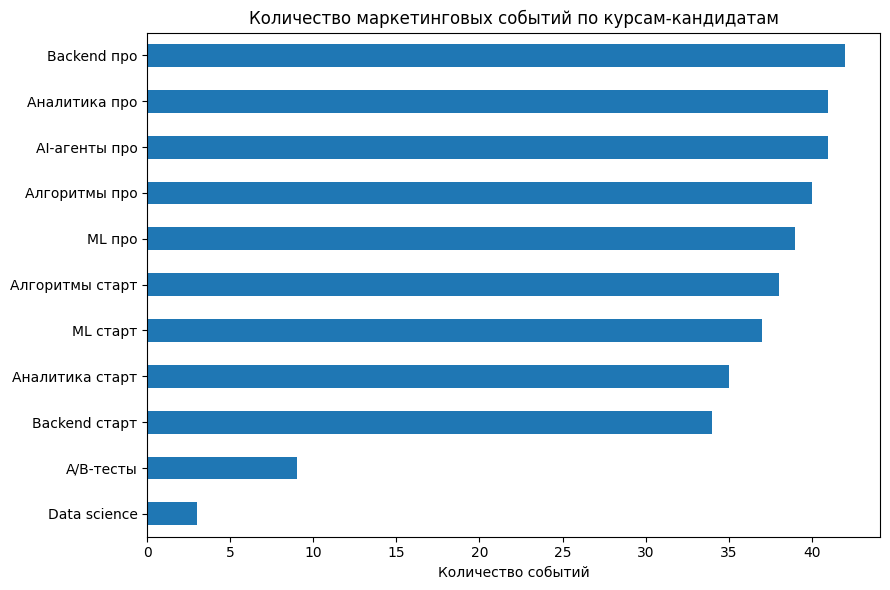

In [49]:
course_stats["events"].sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Количество маркетинговых событий по курсам-кандидатам")
plt.xlabel("Количество событий")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 8. Просмотры и реакции

Посмотрим на распределение охвата публикаций.

Метрики вовлечённости не являются прямой оценкой продаж,
но позволяют сравнивать масштаб различных маркетинговых событий.

In [51]:
for col in ["views", "reactions"]:
    marketing[col] = pd.to_numeric(marketing[col], errors="coerce")

In [52]:
marketing[["views", "reactions"]].describe().round(1)

,views,reactions
count,210.0,189.0
mean,10185.4,42.8
std,8578.5,63.2
min,352.0,1.0
25%,2152.5,7.0
50%,6485.0,24.0
75%,18675.0,49.0
max,35200.0,464.0


## 9. Динамика маркетинговой активности

Посмотрим, как менялось количество маркетинговых событий во времени.

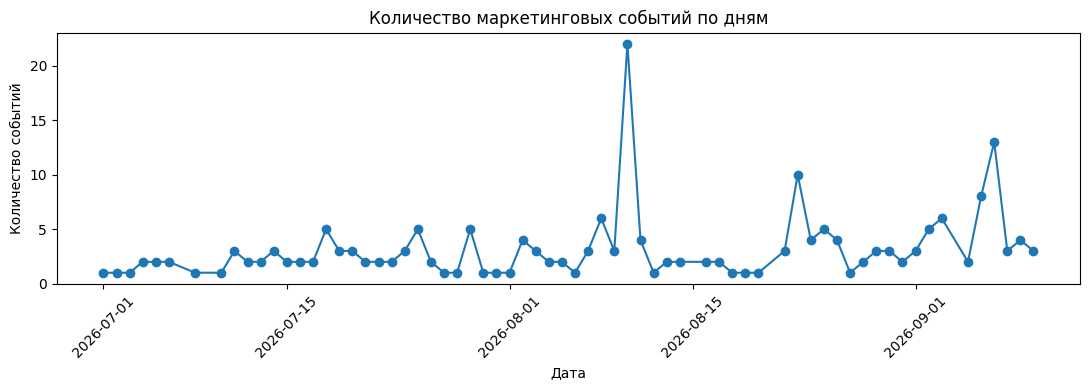

In [54]:
events_daily = (
    marketing
    .groupby(marketing["event_time"].dt.date)
    .size()
)

events_daily.plot(
    figsize=(11, 4),
    marker="o"
)

plt.title("Количество маркетинговых событий по дням")
plt.xlabel("Дата")
plt.ylabel("Количество событий")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

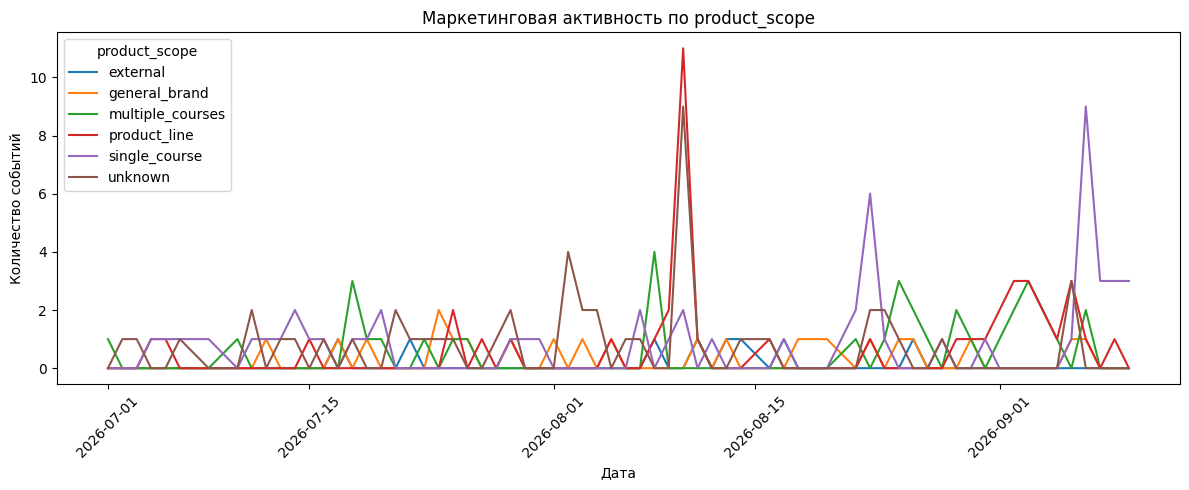

In [55]:
daily_by_scope = (
    marketing
    .groupby([
        marketing["event_time"].dt.date,
        "product_scope"
    ])
    .size()
    .unstack(fill_value=0)
)

daily_by_scope.plot(
    figsize=(12, 5)
)

plt.title("Маркетинговая активность по product_scope")
plt.xlabel("Дата")
plt.ylabel("Количество событий")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()